In [4]:
#basic
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Predictive Maintenance: Machine Failure Prediction
This project aims to predict milling machine failures using sensor data (temperature, torque, speed, etc.).
Predicting failures before they happen allows for scheduled maintenance, reducing downtime and costs.

### Key Technical Challenges:
* **Imbalanced Data:** Only 3.4% of the machines fail.
* **Leakage Prevention:** Removing features that reveal the outcome before the prediction is made.
* **Robust Validation:** Using Monte Carlo simulations to ensure model stability.





In [5]:
df=pd.read_csv('/content/ai4i2020.xls')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
y=df['Machine failure']
X=df.drop(['Machine failure','UDI','Product ID','TWF', 'HDF', 'PWF', 'OSF', 'RNF'],axis=1)



# **EDA (Exploration Data Analysis)**

<Axes: title={'center': 'Histogram of Type'}, xlabel='Type', ylabel='Count'>

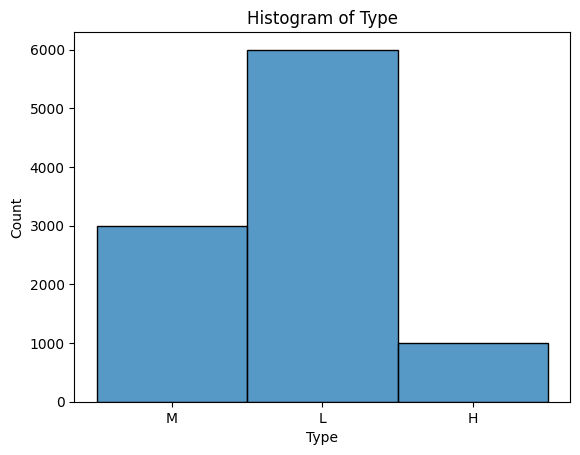

In [8]:
plt.title('Histogram of Type')
sns.histplot(x='Type',data=df)

<Axes: title={'center': 'Machine Failure Countplot'}, xlabel='Machine failure', ylabel='count'>

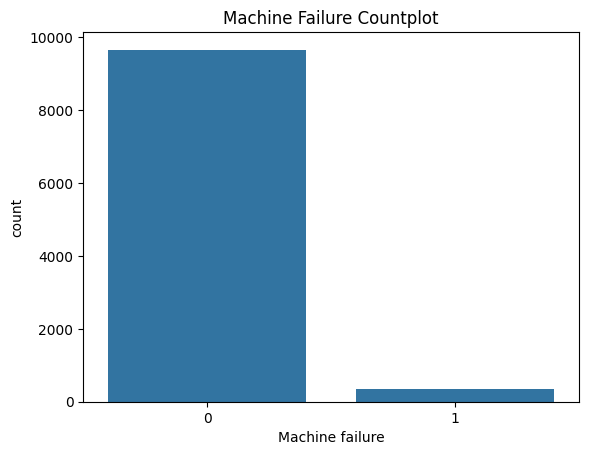

In [9]:
plt.title('Machine Failure Countplot')
sns.countplot(x='Machine failure',data=df)

array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

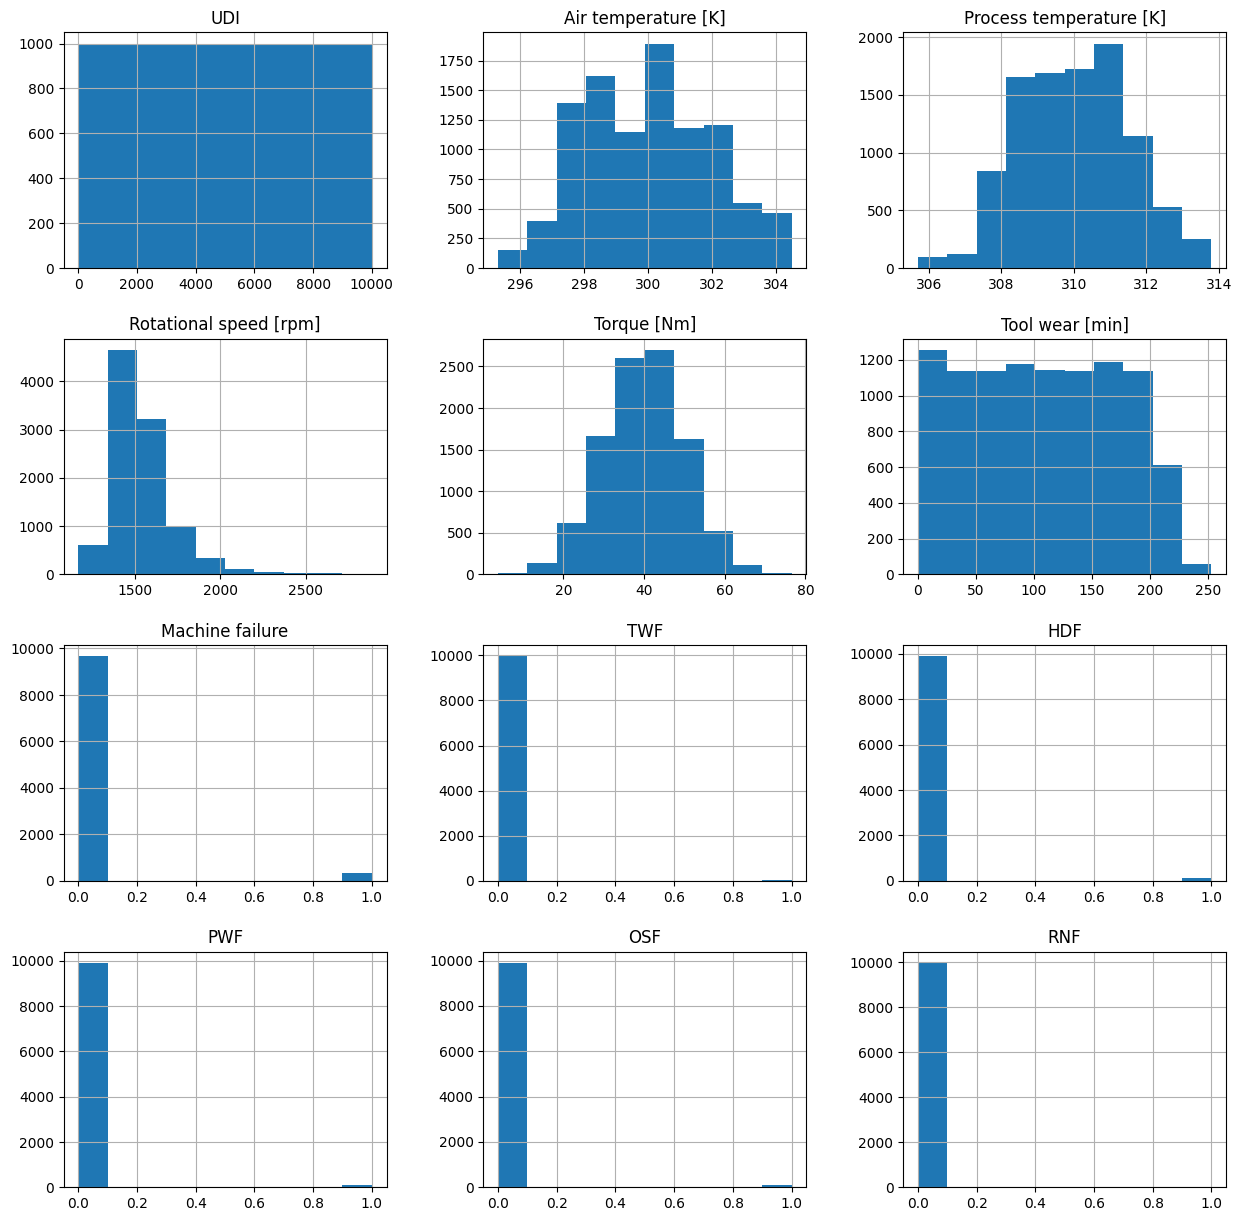

In [36]:
df.hist(figsize=(15,15))

<Axes: >

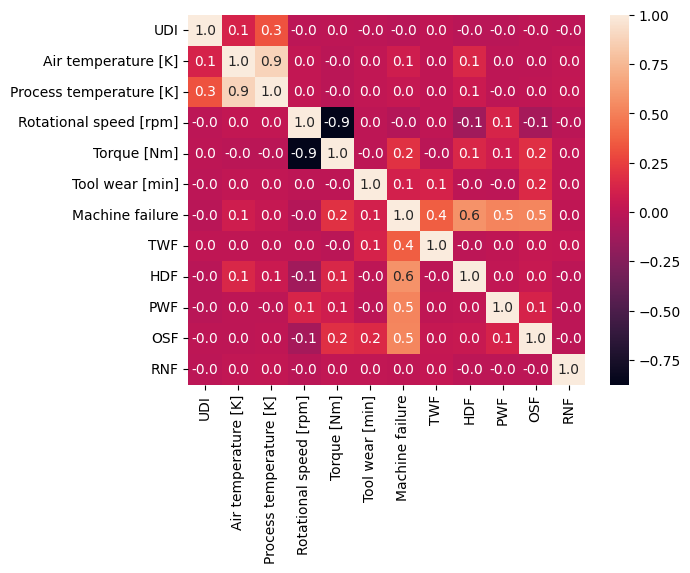

In [14]:
df_num=df.select_dtypes(include=['number'])
df_num=df_num.drop(['UDI','Machine failure','TWF', 'HDF', 'PWF', 'OSF', 'RNF'],axis=1)
df_cat=df.select_dtypes(include=['object'])
df_cat=df_cat.drop('Product ID',axis=1)
df2=df.copy()
df2=df.select_dtypes(include=['number'])
df2.drop(['UDI'],axis=1)
sns.heatmap(df2.corr(),annot=True,fmt='.1f')

<Axes: title={'center': 'Torque vs Machine Failure BoxPlot'}, xlabel='Machine failure', ylabel='Torque [Nm]'>

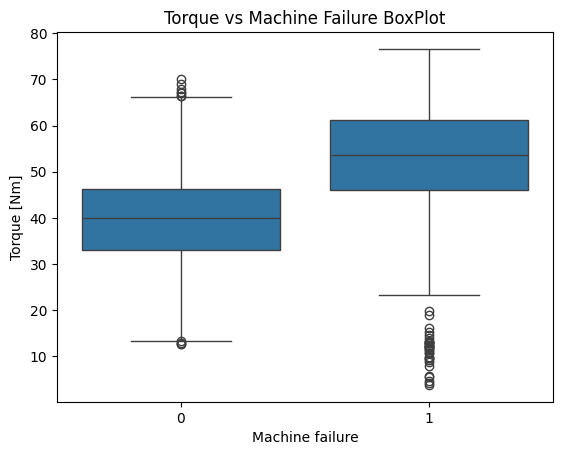

In [15]:
plt.title('Torque vs Machine Failure BoxPlot')
sns.boxplot(x='Machine failure',y='Torque [Nm]',data=df)

<Axes: title={'center': 'Air Temperature vs Machine Failure BoxPlot'}, xlabel='Machine failure', ylabel='Air temperature [K]'>

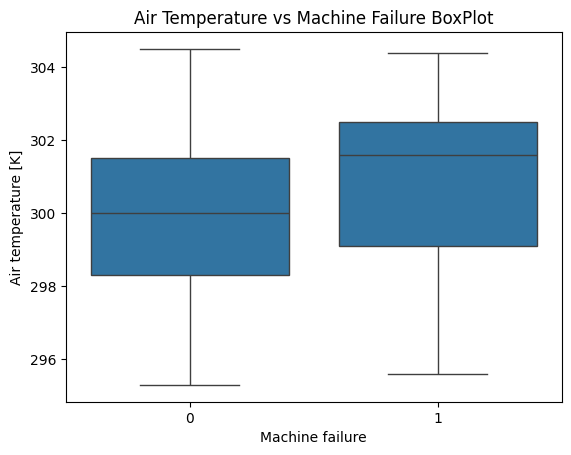

In [16]:
plt.title('Air Temperature vs Machine Failure BoxPlot')
sns.boxplot(x='Machine failure',y='Air temperature [K]',data=df)

<Axes: title={'center': 'Tool wear vs Machine Failure BoxPlot'}, xlabel='Machine failure', ylabel='Tool wear [min]'>

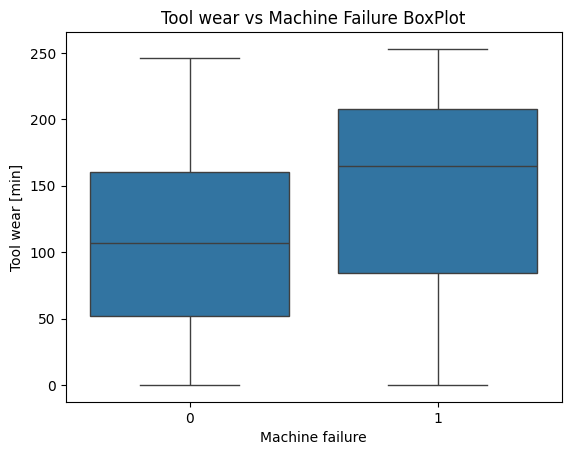

In [17]:
plt.title('Tool wear vs Machine Failure BoxPlot')
sns.boxplot(x='Machine failure',y='Tool wear [min]',data=df)

## Data Pipeline and Feature Engineering
We use a `Scikit-Learn Pipeline` to ensure that preprocessing (Scaling and One-Hot Encoding)
is strictly applied within cross-validation folds, preventing any data leakage from the test set.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,cross_val_score,ShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay,classification_report,confusion_matrix

In [19]:
num_cols=list(df_num.columns)
cat_cols=list(df_cat.columns)

In [20]:

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#Num
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
#OneHotEncoder
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

final_pipeline=Pipeline(steps=[('preprocess',preprocessor),
 ('model',RandomForestClassifier(class_weight='balanced',n_estimators=100,max_depth=5))])

In [21]:
final_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5))])

## Model Stability: Monte Carlo Simulation
Because the dataset is small in terms of failure events, we run a **Monte Carlo Cross-Validation** with 200 iterations. This gives us a confidence interval for our F1-score, proving the
model isn't just "getting lucky" on a specific data split.

F1-Score Mean: 0.9354
IC (95%): 0.9196 a 0.9513


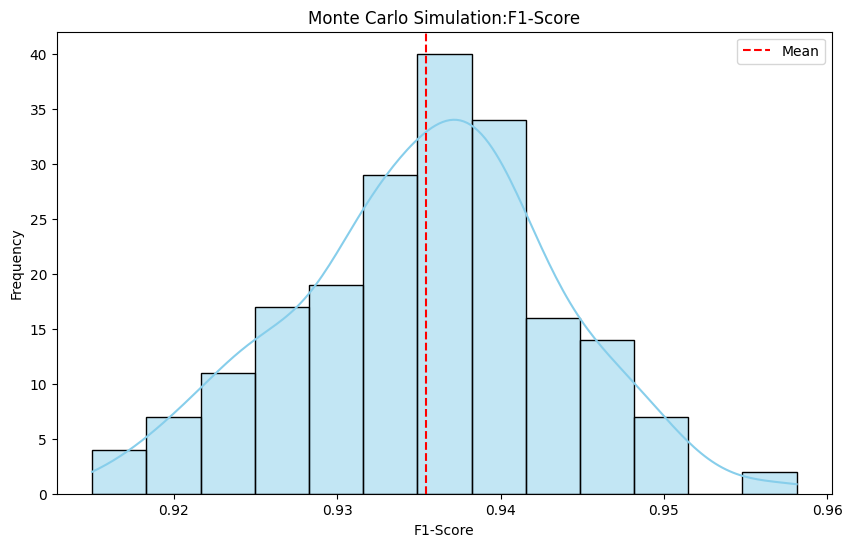

In [22]:
monte_carlo=ShuffleSplit(n_splits=200,test_size=0.2,random_state=42)
cv_results=cross_val_score(final_pipeline,X_train,y_train,cv=monte_carlo,scoring='accuracy')

print(f"F1-Score Mean: {cv_results.mean():.4f}")
print(f"IC (95%): {cv_results.mean() - 2*cv_results.std():.4f} a {cv_results.mean() + 2*cv_results.std():.4f}")

plt.figure(figsize=(10, 6))
sns.histplot(cv_results, kde=True, color='skyblue')
plt.title('Monte Carlo Simulation:F1-Score')
plt.xlabel('F1-Score')
plt.ylabel('Frequency')
plt.axvline(cv_results.mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()

ROC-AUC Score: 0.9551


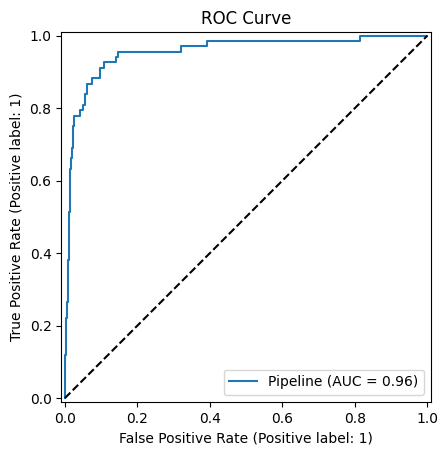

              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.29      0.88      0.44        68

    accuracy                           0.92      2000
   macro avg       0.64      0.90      0.70      2000
weighted avg       0.97      0.92      0.94      2000



In [28]:
y_probs = final_pipeline.predict_proba(X_val)[:, 1]
auc_value = roc_auc_score(y_val, y_probs)
print(f"ROC-AUC Score: {auc_value:.4f}")
RocCurveDisplay.from_estimator(final_pipeline, X_val, y_val)
plt.plot([0, 1], [0, 1], 'k--') # Línia d'atzar
plt.title('ROC Curve')
plt.show()
y_pred = final_pipeline.predict(X_val)
print(classification_report(y_val,y_pred))

## Precision-Recall Analysis
In imbalanced datasets, the ROC curve can be overly optimistic. The **Precision-Recall Curve** is a more rigorous metric for this use case, showing how well the model identifies
the minority class (Failures) without generating too many false alarms.

Visualitzant Precision-Recall Curve...


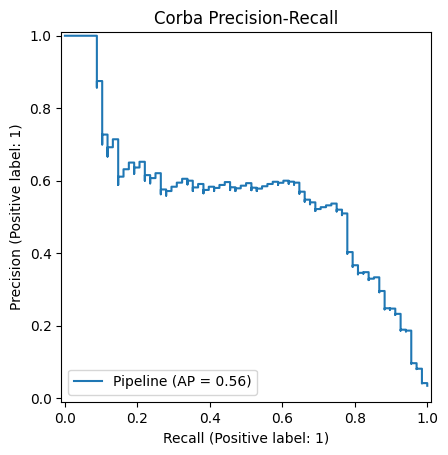

In [25]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(final_pipeline, X_val, y_val)
plt.title('Curve Precision-Recall')
plt.show()

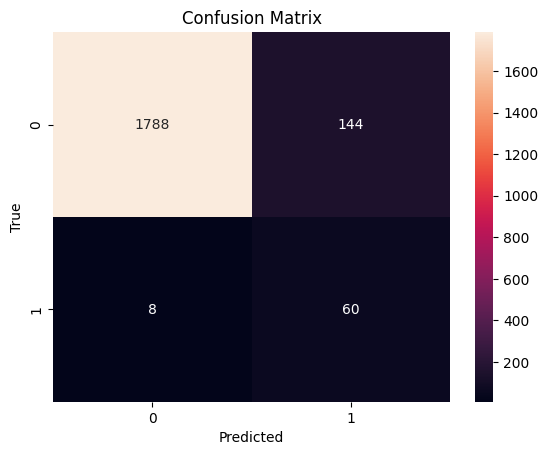

In [34]:
plt.title('Confusion Matrix')
sns.heatmap(confusion_matrix(y_val,y_pred),annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

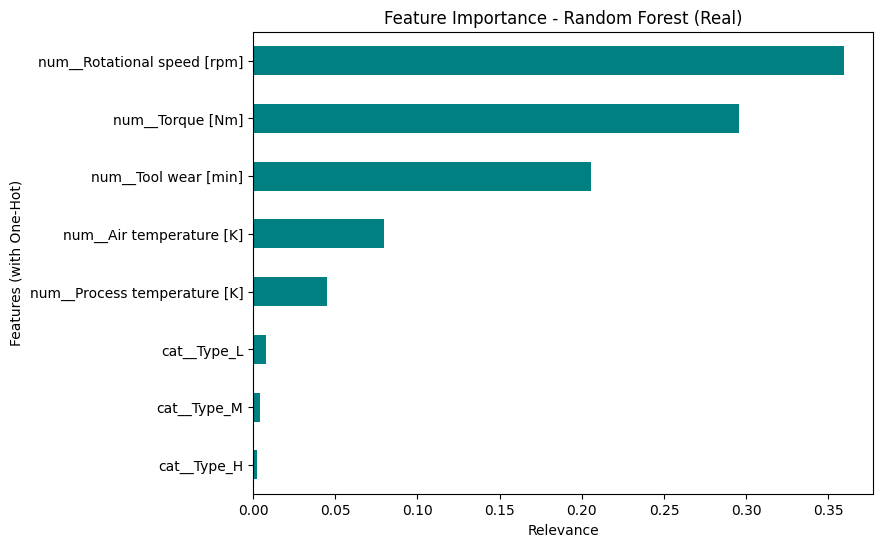

In [39]:

noms_columnes = final_pipeline.named_steps['preprocess'].get_feature_names_out()
importancies_valors = final_pipeline.named_steps['model'].feature_importances_
importances = pd.Series(importancies_valors, index=noms_columnes).sort_values(ascending=True)
importances.plot(kind='barh', color='teal', figsize=(8,6))
plt.title("Feature Importance - Random Forest (Real)")
plt.xlabel("Relevance")
plt.ylabel("Features (with One-Hot)")
plt.show()

## Model Optimization: Hyperparameter Tuning
While the initial Random Forest provides a solid baseline, we can further refine its performance by searching for the optimal set of hyperparameters.

We use **GridSearchCV** to exhaustively test different combinations of:
* `n_estimators`: The number of trees in the forest.
* `max_depth`: The maximum depth of each tree (to control overfitting).
* `class_weight`: Specifically 'balanced' or 'balanced_subsample' to further assist the model in learning from the rare failure events.

**Optimization Metric:** We continue to use the **F1-Score** as our primary metric for the grid search, ensuring a balanced trade-off between identifying all failures (Recall) and minimizing false alarms (Precision).


In [41]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100,150, 200],
    'model__max_depth': [5, 10, None],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

grid_search = GridSearchCV(final_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
final_model = grid_search.best_estimator_

Best parameters: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__n_estimators': 200}


## Business Value: Economic Impact Analysis
In industrial environments, machine learning models are evaluated by their ability to save money. Accuracy alone doesn't tell the whole story because the costs of errors are asymmetrical:

1. **False Negative (Type II Error):** The model predicts "No Failure," but the machine breaks down.
   * **Impact:** Unplanned downtime, potential damage to other parts, and emergency repair costs. This is the **most expensive** error.
2. **False Positive (Type I Error):** The model predicts a "Failure," but the machine is fine.
   * **Impact:** Unnecessary maintenance check and technician labor costs. This is a **low-cost** error.

Below, we define a cost function to estimate the potential savings of implementing this Predictive Maintenance model compared to a traditional "Run-to-Failure" strategy.

In [42]:
def estimate_savings(y_true, y_pred):
    # Costs (Estimated)
    cost_missed_failure = 5000  # Cost of a breakdown
    cost_false_alarm = 500     # Cost of technician time

    # Without model
    total_failures = y_true.sum()
    cost_no_model = total_failures * cost_missed_failure

    # With model (predective)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost_with_model = (fn * cost_missed_failure) + (fp * cost_false_alarm)

    return cost_no_model, cost_with_model

no_model, with_model = estimate_savings(y_val, final_model.predict(X_val))
print(f"Cost without ML model: {no_model}€")
print(f"Cost with ML Model: {with_model}€")
print(f"Total Savings: {no_model - with_model}€")

Cost without AI: 340000€
Cost with AI: 146000€
Total Savings: 194000€


## **Conclusions and Future Work**
### Summary
* The model successfully identifies machine failures with a high degree of confidence.
* By using **balanced class weights** and **Monte Carlo validation**, we've ensured the results are robust and not biased by the majority class (non-failures).
* Key predictors identified include **Torque** and **Rotational Speed**, which aligns with mechanical failure patterns in milling machines.

### Future Improvements
* **Feature Engineering:** Creating interaction features like Power (Torque × Speed) could improve the decision boundary.
* **Deployment:** Exporting this pipeline using `joblib` or `pickle` for integration into a real-time IoT monitoring system.
* **Anomaly Detection:** Testing unsupervised methods (like Isolation Forests) to detect "unknown" types of failures.

In [43]:
import joblib

joblib.dump(final_model, 'predictive_maintenance_model.pkl')

['predictive_maintenance_model.pkl']

SyntaxError: invalid syntax (ipython-input-1609277159.py, line 1)